# 01 — Data Exploration

Understand bandit log structure before building estimators.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
RES_DIR  = Path('../results')
RES_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv(DATA_DIR / 'bandit_data.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (20000, 25)
Columns: ['user_id', 'action', 'reward', 'logging_policy_prob', 'timestamp', 'ctx_0', 'ctx_1', 'ctx_2', 'ctx_3', 'ctx_4', 'ctx_5', 'ctx_6', 'ctx_7', 'ctx_8', 'ctx_9', 'ctx_10', 'ctx_11', 'ctx_12', 'ctx_13', 'ctx_14', 'ctx_15', 'ctx_16', 'ctx_17', 'ctx_18', 'ctx_19']


,user_id,action,reward,logging_policy_prob,timestamp,ctx_0,ctx_1,ctx_2,ctx_3,ctx_4,...,ctx_10,ctx_11,ctx_12,ctx_13,ctx_14,ctx_15,ctx_16,ctx_17,ctx_18,ctx_19
0,196,241,0.0,0.000695,881250949,0.559148,0.185320,-0.107952,0.241163,-0.490365,...,0.145349,-0.099395,0.004749,0.060241,-0.034588,0.073064,0.188522,-0.115366,0.015549,0.062190
1,186,300,0.0,0.000786,891717742,0.647983,-0.354833,0.139577,0.085564,0.156997,...,-0.224239,0.214308,-0.085699,-0.034711,-0.113613,0.127351,-0.047723,-0.060166,0.109219,-0.031407
2,22,375,0.0,0.000586,878887116,0.851149,-0.180256,0.007166,-0.070612,0.037300,...,-0.052452,-0.049530,0.101122,-0.048859,0.059306,-0.092593,-0.016768,0.068770,-0.027316,-0.013017


## Schema breakdown

In [3]:
ctx_cols = [c for c in df.columns if c.startswith('ctx_')]
print(f'Context dims : {len(ctx_cols)}')
print(f'Actions (items): {df.action.nunique()}')
print(f'Reward mean    : {df.reward.mean():.3f}')
print(f'Min propensity : {df.logging_policy_prob.min():.6f}')
print(f'Max IPS weight : {(1/df.logging_policy_prob).max():.1f}')

Context dims : 20
Actions (items): 1410
Reward mean    : 0.562
Min propensity : 0.000458
Max IPS weight : 2182.5


## Propensity analysis

Low propensities → extreme IPS weights → high variance. This is the core OPE challenge.

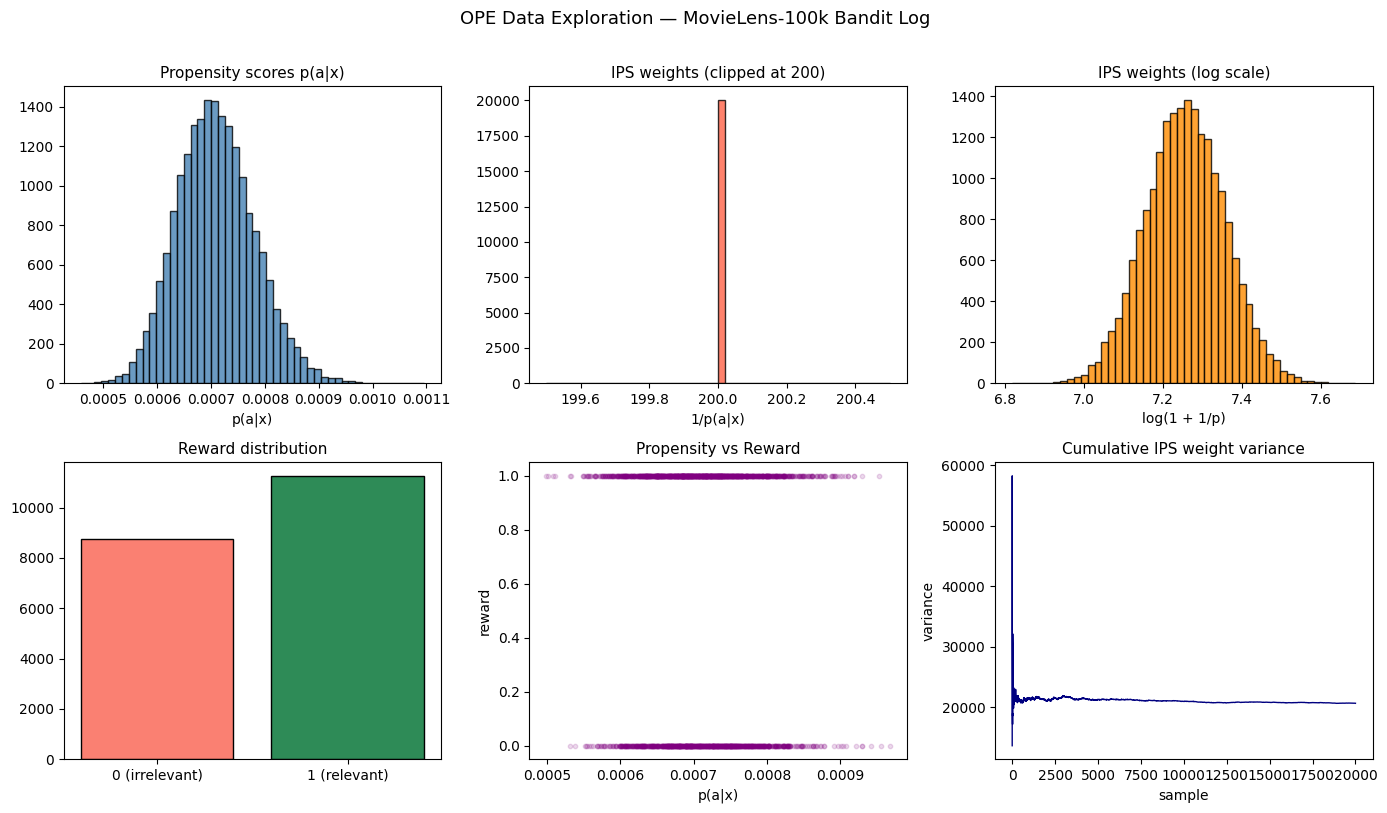

In [4]:
ips_weights = 1.0 / df['logging_policy_prob']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Propensity histogram
axes[0,0].hist(df['logging_policy_prob'], bins=50, color='steelblue', edgecolor='k', alpha=0.8)
axes[0,0].set_title('Propensity scores p(a|x)', fontsize=11)
axes[0,0].set_xlabel('p(a|x)')

# IPS weight histogram (raw)
axes[0,1].hist(ips_weights.clip(0, 200), bins=50, color='tomato', edgecolor='k', alpha=0.8)
axes[0,1].set_title('IPS weights (clipped at 200)', fontsize=11)
axes[0,1].set_xlabel('1/p(a|x)')

# IPS weight log scale
axes[0,2].hist(np.log1p(ips_weights), bins=50, color='darkorange', edgecolor='k', alpha=0.8)
axes[0,2].set_title('IPS weights (log scale)', fontsize=11)
axes[0,2].set_xlabel('log(1 + 1/p)')

# Reward distribution
axes[1,0].bar([0,1], df['reward'].value_counts().sort_index().values, color=['salmon','seagreen'], edgecolor='k')
axes[1,0].set_title('Reward distribution', fontsize=11)
axes[1,0].set_xticks([0,1]); axes[1,0].set_xticklabels(['0 (irrelevant)','1 (relevant)'])

# Propensity vs reward
axes[1,1].scatter(df['logging_policy_prob'].sample(2000, random_state=0),
                  df['reward'].sample(2000, random_state=0),
                  alpha=0.15, s=10, color='purple')
axes[1,1].set_title('Propensity vs Reward', fontsize=11)
axes[1,1].set_xlabel('p(a|x)'); axes[1,1].set_ylabel('reward')

# Cumulative IPS weight variance over samples
cum_var = pd.Series(ips_weights.values).expanding().var()
axes[1,2].plot(cum_var.values, color='navy', lw=1)
axes[1,2].set_title('Cumulative IPS weight variance', fontsize=11)
axes[1,2].set_xlabel('sample'); axes[1,2].set_ylabel('variance')

plt.suptitle('OPE Data Exploration — MovieLens-100k Bandit Log', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / '01_data_exploration.png', dpi=100, bbox_inches='tight')
plt.show()

## Context embedding visualization (PCA)

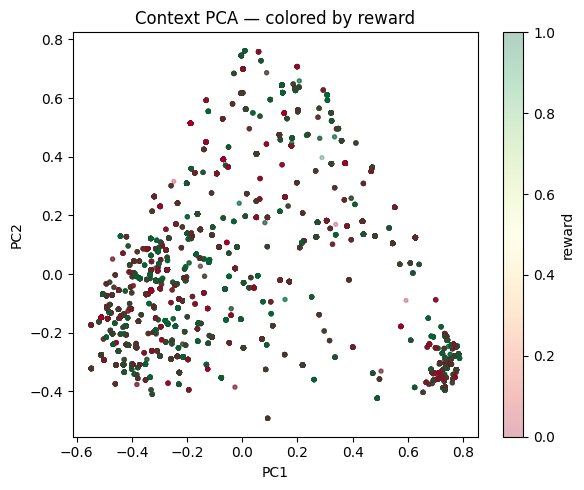

PCA explained variance: 42.16%


In [5]:
from sklearn.decomposition import PCA

X = df[ctx_cols].values
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=df['reward'], cmap='RdYlGn', alpha=0.3, s=8)
plt.colorbar(label='reward')
plt.title('Context PCA — colored by reward')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig(RES_DIR / '01_context_pca.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}')

## Key observations for OPE

| Issue | Impact on estimator |
|-------|--------------------|
| Low propensities exist | IPS variance explodes |
| Binary reward (0/1) | DM needs good classifier |
| 20-dim context | Representation learning feasible |
| Temporal order in data | Sequential modeling applicable |

In [8]:
# Save processed split for downstream notebooks
np.random.seed(42)
idx = np.random.permutation(len(df))
train_end = int(0.6 * len(df))
val_end   = int(0.8 * len(df))

train_df = df.iloc[idx[:train_end]]
val_df   = df.iloc[idx[train_end:val_end]]
test_df  = df.iloc[idx[val_end:]]

train_df.to_csv(DATA_DIR / 'train.csv', index=False)
val_df.to_csv(DATA_DIR   / 'val.csv',   index=False)
test_df.to_csv(DATA_DIR  / 'test.csv',  index=False)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 12000 | Val: 4000 | Test: 4000
